In [2]:
import pandas as pd

In [ ]:
import os

os.chdir("..")

In [4]:
df = pd.read_csv("data/raw/Fraud_Data.csv")

In [5]:
df.columns
df.shape

(151112, 11)

In [6]:
df.isnull().sum()
df.duplicated().sum()
df = df.drop_duplicates()

In [7]:
df['signup_time'] = pd.to_datetime(df['signup_time'])
df['purchase_time'] = pd.to_datetime(df['purchase_time'])

<Axes: xlabel='age', ylabel='Count'>

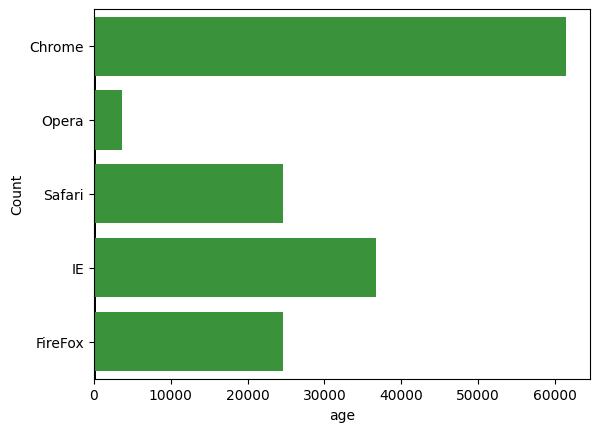

In [10]:
sns.histplot(df['age'])
sns.histplot(df['purchase_value'])
sns.countplot(y='browser', data=df)

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
import pandas as pd

df = pd.read_csv("../data/raw/Fraud_Data.csv")

In [5]:
df.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


In [6]:
df.shape

(151112, 11)

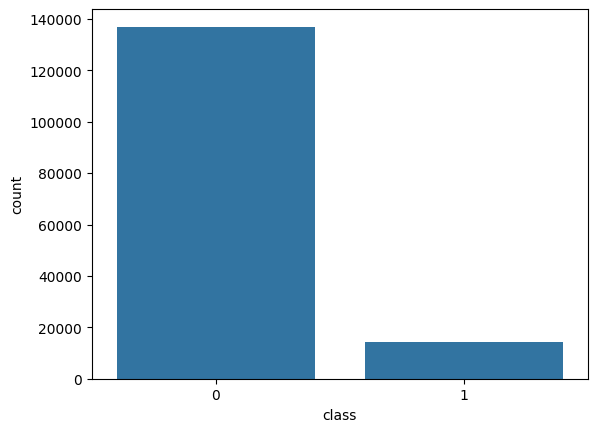

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='class', data=df)
plt.show()

<Axes: xlabel='class', ylabel='count'>

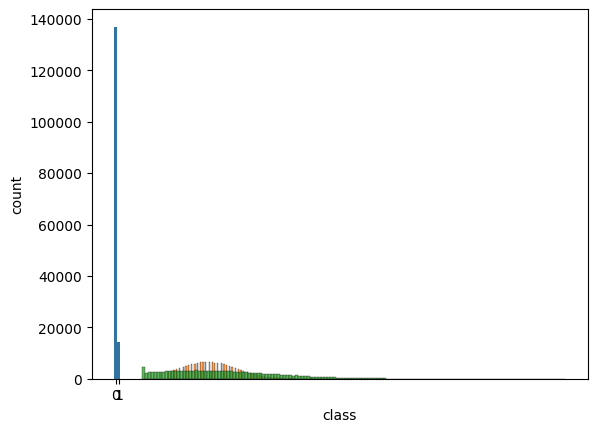

In [8]:
sns.countplot(x='class', data=df)
sns.histplot(df['age'])
sns.histplot(df['purchase_value'])

<Axes: xlabel='class', ylabel='age'>

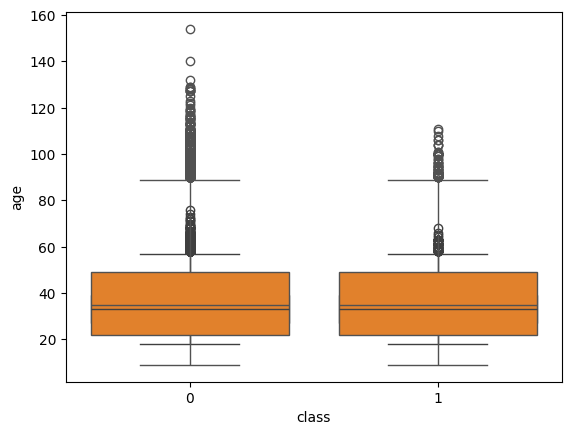

In [9]:
sns.boxplot(x='class', y='age', data=df)
sns.boxplot(x='class', y='purchase_value', data=df)

In [10]:
pd.crosstab(df['browser'], df['class'])
pd.crosstab(df['source'], df['class'])

class,0,1
source,,
Ads,54368,5513
Direct,27390,3226
SEO,55203,5412


Fraud cases are much smaller than non-fraud cases, showing strong class imbalance.
Older users do not significantly differ in fraud probability.

# Geolocation Integration

In [11]:
df['ip_address'] = df['ip_address'].astype(int)

In [12]:
ip_df = pd.read_csv("../data/raw/IpAddress_to_Country.csv")

In [14]:
def get_country(ip):
    match = ip_df[
        (ip_df['lower_bound_ip_address'] <= ip) &
        (ip_df['upper_bound_ip_address'] >= ip)
    ]
    if len(match) > 0:
        return match.iloc[0]['country']
    return None

df['country'] = df['ip_address'].apply(get_country)

In [15]:
df.groupby('country')['class'].mean().sort_values(ascending=False)

country
Turkmenistan             1.000000
Namibia                  0.434783
Sri Lanka                0.419355
Luxembourg               0.388889
Virgin Islands (U.S.)    0.333333
                           ...   
Uganda                   0.000000
Vanuatu                  0.000000
Yemen                    0.000000
Zambia                   0.000000
Zimbabwe                 0.000000
Name: class, Length: 181, dtype: float64

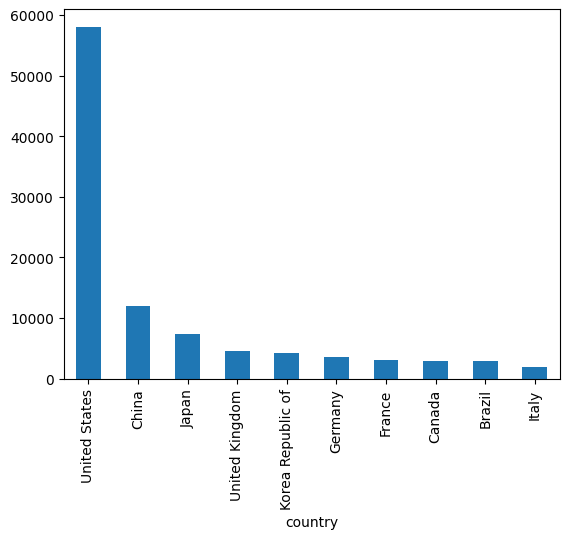

In [16]:
df['country'].value_counts().head(10).plot(kind='bar')
plt.show()